# Machine learning - Classification de tweets scientifiques

## CONFIGURATION

In [114]:
######################################################
# CONFIGURATION & NETTOYAGE DES IMPORTS
######################################################

# --- Gestion des alertes & Système ---
import warnings
import os
from os import sep
import sys
import re
import unicodedata
from pathlib import Path
from typing import Dict

from sqlalchemy import false

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# --- Calcul scientifique & Manipulation de données ---
import numpy as np
import pandas as pd
from numpy.typing import NDArray

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

# --- Traitement du Langage Naturel (NLP) ---
import spacy
import emoji
from sklearn.feature_extraction.text import TfidfVectorizer

# Chargement du modèle SpaCy (Anglais)
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    # Commande à lancer si non installé : python -m spacy download en_core_web_sm
    print("nlp n'a pas pu être importé.")
    pass

# --- Machine Learning : Scikit-Learn ---
# Prétraitement & Transformation
from sklearn.preprocessing import (
    StandardScaler, FunctionTransformer
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA

# Validation & Sélection de modèles
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score
)

from sklearn.pipeline import Pipeline # ça n'est plus utile depuis qu'on utilise ImbPipeline

# Modèles (Classifieurs)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Évaluation & Interprétabilité
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

# --- Gestion du Déséquilibre des classes (Imbalanced-learn) ---
from imblearn.pipeline import Pipeline as ImbPipeline # adri2 : nécessaire si on veut utiliser les librairies ci-dessous

# Imports pour les méthodes d'équilibrage
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# --- Optimisation & Persistance ---
import optuna
import joblib

######################################################
# VÉRIFICATION DES VERSIONS
######################################################
print(f"Pandas: {pd.__version__}")
print(f"Scikit-Learn: {sys.modules['sklearn'].__version__}")
try:
    import imblearn
    print(f"Imbalanced-Learn: {imblearn.__version__}")
except:
    print("Imbalanced-Learn non installé.")

Pandas: 3.0.1
Scikit-Learn: 1.8.0
Imbalanced-Learn: 0.14.2


In [115]:
df = pd.read_csv(".." + sep + "data" + sep + "scitweets_export.tsv", sep='\t')
df.head()

,Unnamed: 0,tweet_id,text,science_related,scientific_claim,scientific_reference,scientific_context
0,0,316669998137483264,Knees are a bit sore. i guess that's a sign th...,0,0.0,0.0,0.0
1,1,319090866545385472,McDonald's breakfast stop then the gym 🏀💪,0,0.0,0.0,0.0
2,2,322030931022065664,Can any Gynecologist with Cancer Experience ex...,1,1.0,0.0,0.0
3,3,322694830620807168,Couch-lock highs lead to sleeping in the couch...,1,1.0,0.0,0.0
4,4,328524426658328576,Does daily routine help prevent problems with ...,1,1.0,0.0,0.0


## NETTOYAGE DES DONNEES

In [116]:
#Nettoyage pour un tweet
def clean_data(tweet, replace_urls, replace_mentions, replace_emojis, replace_hashtags, remove_punctuation):
    # Sécurité : si la ligne est vide ou n'est pas du texte
    if not isinstance(tweet, str):
        return ""
        
    tweet = tweet.lower()
    
    if replace_urls:
        tweet = re.sub(r'http\S+', 'url', tweet) # Remplace les URLs par "URL"
    if replace_mentions:
        tweet = re.sub(r'@\w+', 'USER', tweet) # Remplace les mentions d'utilisateur par "USER"
    if replace_emojis:
        tweet = emoji.replace_emoji(tweet, replace=' EMOJI ') # Remplace les emojis par "EMOJI"
    if replace_hashtags == 1:
        tweet = re.sub(r'#(\w+)', r'hashtag_\1', tweet) # Remplace les hashtags par "hashtag_mot"
    if replace_hashtags == 2:
        tweet = re.sub(r'#(\w+)', 'HASHTAG', tweet) # Remplace les hashtags par "HASHTAG"
    if replace_hashtags == 3:
        pass # Ne fait rien, les hashtags restent tels quels / les "#" seront supprimés juste après grace à la ponctuation
    if remove_punctuation:
        tweet = re.sub(r'[^\w\s]', '', tweet) # Supprime la ponctuation
    
    tweet = unicodedata.normalize('NFKD', tweet).encode('ascii','ignore').decode('utf-8') #Enlève les accents
    # On fait passer dans Spacy le GOAT
    # nlp crée un pipeline : il tokenise, étiquetage grammatical(tag), lemnise, voit les stopwords... le GOAT quoi
    doc = nlp(tweet)
    
    # On lui dit ce qu'on veut récup
    tokens = []

    for token in doc:
        t = token.lemma_ 
        if (not token.is_stop #Enlève stopwords
                and (token.pos_ in ['NOUN', 'ADJ', 'VERB', 'PROPN'] #Garde nom, adj, verbe, noms propres
                or "hashtag_" in t #On garde le mot "hashtag_"
                or t == "emoji") #Et le mot emoji
                and len(t) > 2): #Enlève les mots de 2 lettres ou moins
            
            tokens.append(t)
    
    return tokens

#Nettoyage pour tous les tweets
def clean_texts(X, urls, mentions, emojis, hashtags, punct):
    return [clean_data(t, urls, mentions, emojis, hashtags, punct) for t in X]



In [117]:
def split_x_y(df, target) -> tuple:
    """
    Filtre les lignes sci si nécessaire et sépare le texte et la cible
    """
    if target != "science_related":
        df = df[df["science_related"] != 0]

    y = df[target]
    X = df["text"]

    return X, y

def add_derived_labels(df):
    """
    Crée les colonnes pour les tâches 2 et 3 :
    - claim_or_ref : {CLAIM, REF} vs {CONTEXT}  (tâche 2)
    - type_assertion : CLAIM vs REF vs CONTEXT   (tâche 3, avec priorité CLAIM > REF > CONTEXT en cas de chevauchement)
    """
    df = df.copy()

    df["claim_or_ref"] = ((df["scientific_claim"] == 1) | (df["scientific_reference"] == 1)).astype(int)

    def assign_single_label(row):
        if row["scientific_claim"] == 1:
            return "CLAIM"
        elif row["scientific_reference"] == 1:
            return "REF"
        else:
            return "CONTEXT"

    df["type_assertion"] = df.apply(assign_single_label, axis=1)

    return df

def cleanAndSplit(dataframe, urls:bool, mentions:bool, emojis:bool, hashtags:int, punct:bool, colonne_y:str):
    """
    Nettoie le texte des tweets puis effectue un split train/test stratifié
    """
    seed = 7    # pour garder en reproductibilité
    X, y = split_x_y(dataframe, target=colonne_y)

    print("Nettoyage du texte en cours...")
    X_cleaned = clean_texts(X, urls, mentions, emojis, hashtags, punct)

    print("Séparation du jeu de données train/test...")
    X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size=0.2, random_state=seed, stratify=y)

    return X_train, X_test, y_train, y_test

## Création des classifieurs

In [118]:
# nécessaire pour le modèle GNB (class_weight)
def get_priors(y_train) -> list:
    # Calcul des poids > ex: 0.52, 10.4
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)

    # Normalisation pour que la somme soit égale à 1 > on divise chaque poids par la somme totale des poids
    priors_normalized = weights / weights.sum()

    return priors_normalized


def get_dico_classifieur(y_train, use_class_weight:bool=False) -> dict:
    result = {}
    # à décommenter uniquement pour faire les tests plus vite
    # return{"SVC":SVC()}

    if use_class_weight:
        result = {"KNN":KNeighborsClassifier(weights="distance"),   # n"a pas de class_weight
            "DT":DecisionTreeClassifier(class_weight="balanced"),
            "GNB":GaussianNB(priors = get_priors(y_train)), # n"a pas de class_weight
            "SVC":SVC(class_weight="balanced"),
            "RF":RandomForestClassifier(class_weight="balanced"),
            "LR":LogisticRegression(class_weight="balanced")}

    else :
        result = {"KNN":KNeighborsClassifier(),   # n"a pas de class_weight
                "DT":DecisionTreeClassifier(),
                "GNB":GaussianNB(), # n"a pas de class_weight
                "SVC":SVC(),
                "RF":RandomForestClassifier(),
                "LR":LogisticRegression()}

    return result

def create_model(classifier_name, params={}):
    """Fonction utilitaire pour centraliser la création des modèles."""
    if classifier_name == "RF":
        return RandomForestClassifier(**params, random_state=42)
    elif classifier_name == "DT":
        return DecisionTreeClassifier(**params, random_state=42)
    elif classifier_name == "SVC":
        return SVC(**params)
    elif classifier_name == "KNN":
        return KNeighborsClassifier(**params)
    elif classifier_name == "GNB":
        return GaussianNB(**params)
    elif classifier_name == "LR":
        return LogisticRegression(**params)
    raise ValueError(f"Classifieur {classifier_name} non supporté.")


def get_param(classifier_name):
    """Fonction utilisaire pour centraliser l'accès aux paramètres des modeles pour optuna"""
    RF_param = {
        "n_estimators": ("int", 10, 150),
        "max_features": ("categorical", ["log2", "sqrt"]),
        "criterion": ("categorical", ["entropy", "gini"]),
        "max_depth": ("int", 2, 15),
        "min_samples_split": ("int", 2, 10),
        "min_samples_leaf": ("int", 1, 10)
    }

    DT_param = {
        "max_depth": ("int", 1, 15),
        "criterion": ("categorical", ["gini", "entropy"]),
        "min_samples_leaf": ("int", 1, 10)
    }

    svc_param = {
        "C": ("float", 1e-3, 1e2, True),
        "gamma": ("categorical", ["scale", "auto", 0.001, 0.01, 0.1, 1.0]),
        "kernel": ("categorical", ["linear", "poly", "rbf"]),
        "degree": ("int", 2, 5),     # Utile uniquement pour le noyau poly
        "class_weight": ("categorical", ["balanced", None])
    }

    KNN_param = {
        "n_neighbors": ("int", 3, 25),
        "weights": ("categorical", ["uniform", "distance"]),
        "algorithm": ("categorical", ["auto", "ball_tree", "kd_tree"])
    }

    GNB_param = {
        "var_smoothing": ("float", 1e-10, 1e-5, True)
    }

    logistic_param = {
        "C": ("float", 1e-2, 1e2, True)
    }

    hyper_param = {
        "KNN": KNN_param,
        "DT": DT_param,
        "GNB": GNB_param,
        "SVC": svc_param,
        "RF": RF_param,
        "LR": logistic_param
    }

    return hyper_param[classifier_name]


## Création du pipeline (TF-IDF -> rééquilibrage -> modèle)

In [119]:
# Nécessaire car les fonctions lambdas ne peuvent pas être sauvegardées
def identity_tokenizer(text):
    return text

def to_dense_array(x):
    return x.toarray()

def getClassifieurPipeline(model, min_df, max_df, ngrams, equilibrage, params=None):
    seed = 7    # reproductibilité

    if params:
        model.set_params(**params)

    # On définit les étapes de base (Vectorisation + Dense)
    steps = [
        ("vectorizer", TfidfVectorizer(
            lowercase=False,
            preprocessor=None,
            tokenizer=identity_tokenizer,
            token_pattern=None,
            max_df=max_df,
            min_df=min_df,
            ngram_range=ngrams,
        )),
        ("to_dense", FunctionTransformer(to_dense_array, accept_sparse=True))
    ]

    # Ajout gestion des déséquilibres de classement seulement si demandé
    if equilibrage == "SMOTE":
        steps.append(("sampler", SMOTE(random_state=seed)))
    elif equilibrage == "copy":
        steps.append(("sampler", RandomOverSampler(random_state=seed))) # equivalent à upsampling_copy
    elif equilibrage == "down":
        steps.append(("sampler", RandomUnderSampler(random_state=seed)))

    # classifieur toujours en dernier
    steps.append(('classifier', model))

    #  IMBLEARN PIPELINE ET NON PLUS DE PIPELINE
    pipeline = ImbPipeline(steps)

    return pipeline

## Visualisation

In [120]:
######################################################
# Chargement du jeu de données
######################################################
def get_pipeline(path_joblib=None):
    ROOT = Path().resolve() / "src"

    if path_joblib is None:
        name = input("nom de la pipeline : ")+".joblib"
        pipeline_path = ROOT / "pipelines" / name
    else:
        pipeline_path = path_joblib
    pipe = joblib.load(pipeline_path)

    return pipe



In [121]:
def boite_a_moustache(results: Dict[str, NDArray[np.float64]], nom_fichier: str = "comparaison_modeles") -> None:
    fig = plt.figure()
    fig.suptitle("Comparaison des algorithmes")
    ax = fig.add_subplot(111)
    
    plt.boxplot(list(results.values()))
    
    # Pour les labels, c'est pareil : on convertit en liste
    ax.set_xticklabels(list(results.keys()))
    IMAGES_DIR = Path("..") / "images"
    IMAGES_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(IMAGES_DIR / f"{nom_fichier}.png", dpi=150, bbox_inches="tight")
    
    plt.show()

def plot_class_distribution(y, class_names=None):
    """
    Affiche la répartition des classes et génère un histogramme.
    Paramètres :
    - y : array-like
    Labels des classes (int ou str).
    - class_names : list, optional
    Noms des classes pour l'axe des x (default: None,
    utilise les valeurs uniques de y).
    """
    # Calculer la répartition des classes
    unique, counts = np.unique(y, return_counts=True)
    print("Répartition des classes :")
    for cls, count in zip(unique, counts):
        print(f"Classe {cls} : {count} échantillons")
    
    # Si aucun nom de classe n'est fourni, utiliser les valeurs uniques de y
    if class_names is None:
        class_names = [f"Classe {cls}" for cls in unique]
    
    # Histogramme de la répartition des classes
    plt.figure(figsize=(6, 4))
    plt.bar(unique, counts, color=['blue', 'orange'], alpha=0.7)
    plt.xticks(unique, class_names)
    plt.ylabel("Nombre d'échantillons")
    plt.title("Répartition des classes")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def plot_confusion_matrix(conf_matrix, title="Matrice de confusion", labels=None, cmap="Blues", nom_fichier: str = None):
    """
    Trace une matrice de confusion sous forme de heatmap.
    Paramètres :
    - conf_matrix : array-like (2D)
    Matrice de confusion .
    - title : str, optional
    Titre du graphique (default : "Matrice de confusion").
    - labels : list, optional
    Liste des noms des classes pour les axes
    (default : None, utilise les indices numériques).
    - cmap : str, optional
    Colormap pour la heatmap (default : "Blues").
    """
    # Générer des labels par défaut si non spécifiés
    if labels is None:
        labels = [f"Classe {i}" for i in range(conf_matrix.shape[0])]
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=cmap,
    xticklabels=labels, yticklabels=labels)
    
    plt.title(title)
    plt.ylabel("Classe Réelle")
    plt.xlabel("Classe Prédite")
    plt.tight_layout()

    if nom_fichier:
        IMAGES_DIR = Path("..") / "images"
        IMAGES_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(IMAGES_DIR / f"{nom_fichier}.png", dpi=150, bbox_inches="tight")

    plt.show()
    
def plot_roc_curve(fpr, tpr, auc_score):    # n'aura pas été utilisé
    """
    Trace la courbe ROC (Receiver Operating Characteristic)
    pour évaluer la performance d'un modèle de classification.
    Paramètres :
    - fpr : array-like
    Taux de faux positifs (False Positive Rate) pour différents seuils.
    - tpr : array-like
    Taux de vrais positifs (True Positive Rate) pour différents seuils.
    - auc_score : float
    Aire sous la courbe ROC (Area Under the Curve, AUC),
    une mesure globale de performance.
    Fonctionnalités :
    - Trace la courbe ROC avec la courbe réelle en bleu.
    - Ajoute une diagonale en rouge indiquant la ligne de référence pour
    un modèle aléatoire.
    - Affiche l'AUC dans la légende.
    ```
    """
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Diagonale
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.4)
    plt.show()

def plot_pca_2d_3d(X, y, title_2d="ACP 2D", title_3d="ACP 3D"):
    """
    Affiche une ACP 2D et 3D pour visualiser la répartition des documents.
    X : matrice de features (numpy array ou matrice creuse)
    y : labels (array-like)
    """
    # Conversion si matrice creuse
    X_dense = X.toarray() if hasattr(X, "toarray") else X
    y = np.array(y)
    # ACP 2D
    pca_2d = PCA(n_components=2, random_state=0)
    X_pca_2d = pca_2d.fit_transform(X_dense)
    # ACP 3D
    pca_3d = PCA(n_components=3, random_state=0)
    X_pca_3d = pca_3d.fit_transform(X_dense)
    # Figure
    fig = plt.figure(figsize=(12, 5))
    # ----- Plot 2D -----
    ax1 = fig.add_subplot(1, 2, 1)
    idx0 = (y == 0)
    idx1 = (y == 1)
    ax1.scatter(X_pca_2d[idx0, 0], X_pca_2d[idx0, 1], alpha=0.6, label="Not science related")
    ax1.scatter(X_pca_2d[idx1, 0], X_pca_2d[idx1, 1], alpha=0.6, label="Science related")
    ax1.set_title(title_2d)
    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")
    ax1.legend()
    # ----- Plot 3D -----
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.scatter(X_pca_3d[idx0, 0], X_pca_3d[idx0, 1], X_pca_3d[idx0, 2], alpha=0.6, label="Not science related")
    ax2.scatter(X_pca_3d[idx1, 0], X_pca_3d[idx1, 1], X_pca_3d[idx1, 2], alpha=0.6, label="Science related")
    ax2.set_title(title_3d)
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    ax2.set_zlabel("PC3")
    plt.tight_layout()
    plt.show()

def word_cloud(df):
    # 1. On exclut les colonnes qui ne sont pas des mots
    cols_to_drop = ['scientific_context', 'scientific_reference', 'scientific_claim', 'science_related', 'tweet_id']
    df_words = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    # 2. On additionne les occurrences et on remplace les espaces par des "_"
    word_counts_brut = df_words.sum().to_dict()
    
    # Création d'un nouveau dictionnaire avec les clés modifiées
    word_counts = {mot.replace(' ', '_'): frequence for mot, frequence in word_counts_brut.items()}
    
    # 3. Création du word cloud
    wc = WordCloud(
        width=800, 
        height=400, 
        background_color="white",
        prefer_horizontal=0.7,      
        relative_scaling=0.5,       
        max_words=200,              
        min_font_size=10,           
        max_font_size=150           
    )
    wc.generate_from_frequencies(word_counts) # Génération basée sur le dictionnaire de fréquences
    
    # 4. Affichage
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()
    
    # (Optionnel) Sauvegarde de l'image
    wc.to_file("wordcloud.png")
    # 1. On exclut les colonnes qui ne sont pas des mots
    cols_to_drop = ['scientific_context', 'scientific_reference', 'scientific_claim', 'science_related', 'tweet_id']
    df_words = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    # 2. On additionne les occurrences de chaque colonne/mot sur tout le dataset
    word_counts = df_words.sum().to_dict()
    
    # 3. Création du word cloud
        # 3. Création du word cloud
    wc = WordCloud(
        width=800, 
        height=400, 
        background_color="white",
        prefer_horizontal=0.7,      # Autorise 30% des mots à être placés à la verticale (imbrication)
        relative_scaling=0.5,       # Accentue la différence de taille entre les mots fréquents et rares
        max_words=200,              # Limite le nombre de mots pour éviter l'effet "bloc"
        min_font_size=10,           # Taille minimum
        max_font_size=150           # Taille maximum très grande pour les gros mots
    )
    wc.generate_from_frequencies(word_counts) # Génération basée sur le dictionnaire de fréquences
    
    # 4. Affichage
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()
    
    # (Optionnel) Sauvegarde de l'image
    wc.to_file("wordcloud.png")

def data_2d_3d_visu(df):

    column_principal = "science_related"

    # Colonnes numériques utilisées pour l'ACP
    cols_for_pca = [
        "scientific_context","scientific_reference","scientific_claim"
    ]

    X_pca = df[cols_for_pca].values

    # Standardisation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_pca)

    # ACP sur 3 composantes
    pca = PCA(n_components=3)
    X_pca_3d = pca.fit_transform(X_scaled)

    df_pca = pd.DataFrame({
        "PC1": X_pca_3d[:, 0],
        "PC2": X_pca_3d[:, 1],
        "PC3": X_pca_3d[:, 2],
        "science_related": df[column_principal]
    })

    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{"type": "xy"}, {"type": "scene"}]],
        subplot_titles=(
            "Projection 2D (PC1, PC2)",
            "Projection 3D (PC1, PC2, PC3)"
        )
    )

    # Scatter 2D à gauche
    fig.add_trace(
        go.Scatter(
            x=df_pca["PC1"],
            y=df_pca["PC2"],
            mode="markers",
            marker=dict(
                color=df_pca[column_principal],
                colorscale="Viridis",
                showscale=True,
                colorbar=dict(title=column_principal)
            ),
            name="2D"
        ),
        row=1,
        col=1
    )

    fig.update_xaxes(title_text="PC1", row=1, col=1)
    fig.update_yaxes(title_text="PC2", row=1, col=1)

    # Scatter 3D à droite
    fig.add_trace(
        go.Scatter3d(
            x=df_pca["PC1"],
            y=df_pca["PC2"],
            z=df_pca["PC3"],
            mode="markers",
            marker=dict(
                size=4,
                color=df_pca[column_principal],
                colorscale="Viridis",
                showscale=False
            ),
            name="3D"
        ),
        row=1,
        col=2
    )

    fig.update_scenes(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
        row=1,
        col=2
    )

    fig.update_layout(
        title="ACP des données de Tweet (2D et 3D)",
        width=900,
        height=450
    )

    fig.show()


## Comparaison des classifieurs et optimisation des hyperparamètres du modèle choisi

In [122]:
class Config:
    """
    Objet config dédié pour gérer proprement la config
    """
    def __init__(self, urls:bool, mentions:bool, emojis:bool, hashtags:int, punct:bool, min_df:int, max_df:float, ngrams:tuple[int], equilibrage:str, colonne_y:str) -> None:
        self.urls:bool = urls
        self.mentions:bool = mentions
        self.emojis:bool = emojis
        self.hashtags:int = hashtags
        self.punct:bool = punct
        self.min_df:int = min_df
        self.max_df:float = max_df
        # 1-2-3
        self.ngrams:tuple[int] = ngrams
        # class_weight, SMOTE, copy, down, None
        self.equilibrage:str = equilibrage
        # "scientific_claim", "science_related", "scientific_claim", "scientific_reference", "scientific_context"
        self.colonne_y:str = colonne_y


In [123]:
def evaluate_classifieur(X_train, y_train, X_test, y_test, min_df, max_df, ngrams, equilibrage, labels = None):
    seed = 7    # Reproductibilité
    results = {}

    use_weights = (equilibrage == "class_weight")

    for name, model in get_dico_classifieur(y_train=y_train,use_class_weight=use_weights).items():
        pipeline = getClassifieurPipeline(model, min_df, max_df, ngrams, equilibrage)
        
        print(f"\n{'='*10} Évaluation de {name} {'='*10}")

        # validation croisée (X_train uniquement)
        kfold = KFold(n_splits=5, random_state=seed, shuffle=True)

        cv_results = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring='accuracy')
        results[name] = cv_results
        
        print(f"KFold Accuracy moyenne : {cv_results.mean():.3f} (+/- {cv_results.std():.3f})")

        # évaluation sur train entier
        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        print(f"Accuracy sur Test Set : {accuracy_score(y_test, y_pred):.3f}")

        print("\nMatrice de confusion :")
        cm = confusion_matrix(y_test, y_pred)
        print(cm)


        """
        # Affichage graphique propre
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not science", "Science"])
        disp.plot(cmap="Blues")
        plt.title(f"Matrice de confusion - {name}")
        plt.show()
        """
        
        print("\nClassification Report :")
        print(classification_report(y_test, y_pred, target_names=labels, zero_division=0))

    boite_a_moustache(results=results, nom_fichier=f"comparaison_modeles_{colonne_y_choisie}")


In [124]:
# Utilisation de Optuna pour automatiser la recherhe des meilleurs hyperparamètres -> plus performant que gridsearch
def objective(trial, classifier_name, X, y, config):
    """Fonction objectif pour Optuna qui évalue un classifieur donné avec des hyperparamètres suggérés."""
        
    params_config = get_param(classifier_name)
        
    if params_config is None:
        raise ValueError(f"Config pour {classifier_name} non trouvée.")
    
    """ vieille version
    chosen_params = {name: trial.suggest_categorical(name, vals) 
                     for name, vals in params_config.items()}
    """
                     
    # nouvelle version où Optuna suggère les paramètres :
    chosen_params = {}
    for name, spec in params_config.items():
        param_type = spec[0] # int, float, categorical
        
        if param_type == "categorical":
            chosen_params[name] = trial.suggest_categorical(name, spec[1])
            
        elif param_type == "int":
            # spec[1] = borne min, spec[2] = borne max
            chosen_params[name] = trial.suggest_int(name, spec[1], spec[2])
            
        elif param_type == "float":
            # spec[1] = borne min, spec[2] = borne max, spec[3] = True/False pour le log
            log_scale = spec[3] if len(spec) > 3 else False
            chosen_params[name] = trial.suggest_float(name, spec[1], spec[2], log=log_scale)
            
    # recup du modele avec les bons params
    use_weights = (config.equilibrage == "class_weight")
    classifieurs = get_dico_classifieur(y, use_class_weight=use_weights)
    pipeline = getClassifieurPipeline(classifieurs[classifier_name], min_df=config.min_df, max_df=config.max_df, ngrams=config.ngrams, equilibrage=config.equilibrage, params=chosen_params)

    # Évaluation
    # score = cross_val_score(model, X, y, cv=5, n_jobs=-1).mean()
    score = cross_val_score(pipeline, X, y, cv=5, n_jobs=-1, scoring="f1_macro").mean()
    return score

def get_best_params_optuna(classifier_name, X_train, y_train, X_test, y_test, config, labels=None):
    """ Fonction pour lancer l'optimisation avec Optuna et évaluer le meilleur modèle sur le set test."""
    print("--------------------------- Optuna ---------------------------\n\n")
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, classifier_name, X_train, y_train, config), n_trials=500)

    print(f"Meilleur score pour {classifier_name} :", round(study.best_value, 3))
    print(f"Meilleurs paramètres pour {classifier_name} :", study.best_params)

    # reconstruction du meilleur modèle pour prédiction finale
    best_params = study.best_params

    use_weights = (config.equilibrage == "class_weight")
    classifieurs = get_dico_classifieur(y_train, use_class_weight=use_weights)
    pipeline = getClassifieurPipeline(classifieurs[classifier_name], min_df=config.min_df, max_df=config.max_df, ngrams=config.ngrams, equilibrage=config.equilibrage, params=best_params)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(f"Accuracy : {accuracy_score(y_test, y_pred)}")


    conf_matrix = confusion_matrix(y_test, y_pred)
    print(f"Matrice de confusion\n{conf_matrix}")

    class_report = classification_report(y_test, y_pred, zero_division=0)
    print(f"Classification report\n{class_report}")

    if labels is None:
        labels = sorted(y_test.unique())

    plot_confusion_matrix(conf_matrix, title="Matrice de confusion", labels=labels, cmap="Blues", nom_fichier=f"matrice_confusion_{classifier_name}_{config.colonne_y}")

    print(f"Accuracy  sur le jeu de test : {round(accuracy_score(y_test, y_pred),3)}")
    return best_params




In [125]:

def save_model(X_train, y_train, X_test, y_test, classifier_name, best_params, config):
    print("###################################\n# SAUVEGARDE\n###################################")
    
    ###
    # Reconstitution du jeu de donnée pour entrainer sur l'ensemble des données sauf 4 servant de mini test (cf cours)
    ###
    # 1. Fusion de toutes les données nettoyées
    X_all = X_train + X_test
    y_all = pd.concat([y_train, y_test]).reset_index(drop=True)
    
    # 2. DISSOCIATION : On met de côté 4 exemples pour la vérification post-sauvegarde
    # On ne les utilise PAS pour le .fit()
    indices_validation = np.random.choice(len(X_all), 4, replace=False)
    
    # Données pour le test final (cachées au modèle)
    X_val_final = [X_all[i] for i in indices_validation]
    y_val_final = y_all.iloc[indices_validation]
    
    # Données pour l'entraînement final (tout le reste)
    X_final_train = [X_all[i] for i in range(len(X_all)) if i not in indices_validation]
    y_final_train = y_all.drop(indices_validation)

    print(f"Taille totale : {len(X_all)}")
    print(f"Entraînement final sur : {len(X_final_train)} échantillons")
    print(f"Validation isolée sur : {len(X_val_final)} échantillons")

    
    ###
    # Gestion chemin svg
    ###
    ROOT = Path().resolve().parent
    name = input("nom de la pipeline : ")+".joblib"
    pipeline_path = ROOT  / "pipelines" / name
    pipeline_path.parent.mkdir(parents=True, exist_ok=True) # Crée le dossier s'il n'existe pas

    ###
    # Création du modele final
    ###
    use_weights = (config.equilibrage == "class_weight")
    classifieurs = get_dico_classifieur(y_final_train, use_class_weight=use_weights)
    pipeline_final = getClassifieurPipeline(classifieurs[classifier_name], min_df=config.min_df, max_df=config.max_df, ngrams=config.ngrams, equilibrage=config.equilibrage, params=best_params)

    print("pipeline créée")
    print(best_params)

    # Entraînement du pipeline sur toutes les données disponibles
    pipeline_final.fit(X_final_train, y_final_train)
    print("modèle entrainée")

    # Sauvegarde du pipeline
    joblib.dump(pipeline_final, pipeline_path)
    print("pipeline saved")
    print(f"Le modèle sera sauvegardé ici : {os.getcwd()}")


    # test sur les 4 données mises de cotées
    # Rechargement du modèle
    print("\n--- Vérification sur les données JAMAIS vues ---")
    loaded_model = joblib.load(pipeline_path)
    print("modèle chargée")

    y_pred = loaded_model.predict(X_val_final)
    print("prediction réalisée")

    vraies_valeurs = list(y_val_final)
    predictions = list(y_pred)

    print("\n--- RÉSULTATS DU TEST ---")

    for i in range(4):
        texte = " ".join(X_val_final[i])
        
        reel = vraies_valeurs[i]
        pense = predictions[i]

        print("Texte :", texte)
        print(f" => Réel : {reel} | Prédit : {pense}")
        print("------------------------------")

## MAIN

Tâches disponibles :
1 -> SCI vs NON-SCI (science_related)
2 -> {CLAIM, REF} vs CONTEXT (claim_or_ref)
3 -> CLAIM vs REF vs CONTEXT (type_assertion)
Nettoyage du texte en cours...
Séparation du jeu de données train/test...
Répartition de la population avant équilibrage
type_assertion
CLAIM      211
REF         63
CONTEXT     26
Name: count, dtype: int64

========== Évaluation de KNN ==========
KFold Accuracy moyenne : 0.520 (+/- 0.082)
Accuracy sur Test Set : 0.333

Matrice de confusion :
[[10  4 38]
 [ 0  2  5]
 [ 2  1 13]]

Classification Report :
              precision    recall  f1-score   support

       CLAIM       0.83      0.19      0.31        52
     CONTEXT       0.29      0.29      0.29         7
         REF       0.23      0.81      0.36        16

    accuracy                           0.33        75
   macro avg       0.45      0.43      0.32        75
weighted avg       0.65      0.33      0.32        75


========== Évaluation de DT ==========
KFold Accuracy moyenne 

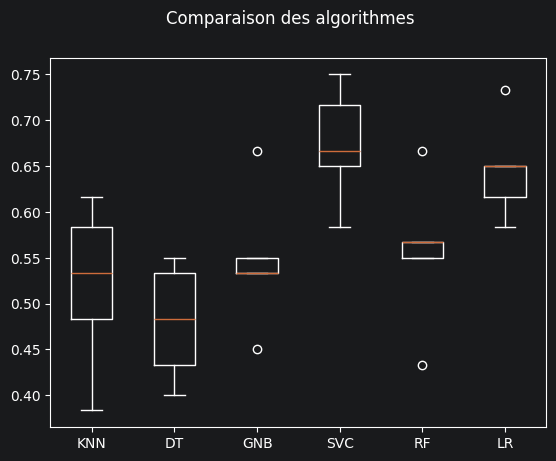

[I 2026-09-02 11:39:45,705] A new study created in memory with name: no-name-7d450bcf-fb07-457f-a16e-f895f7bc4cd6
[I 2026-09-02 11:39:45,863] Trial 0 finished with value: 0.3074974576533562 and parameters: {'C': 39.128639097846246, 'gamma': 'scale', 'kernel': 'poly', 'degree': 4, 'class_weight': None}. Best is trial 0 with value: 0.3074974576533562.


--------------------------- Optuna ---------------------------




[I 2026-09-02 11:39:46,012] Trial 1 finished with value: 0.3282994148154311 and parameters: {'C': 0.047548439942320476, 'gamma': 0.1, 'kernel': 'poly', 'degree': 5, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.3282994148154311.
[I 2026-09-02 11:39:46,147] Trial 2 finished with value: 0.5185310992783331 and parameters: {'C': 0.019240564395263112, 'gamma': 1.0, 'kernel': 'rbf', 'degree': 4, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.5185310992783331.
[I 2026-09-02 11:39:46,259] Trial 3 finished with value: 0.5185310992783331 and parameters: {'C': 0.001605753266397845, 'gamma': 1.0, 'kernel': 'rbf', 'degree': 3, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.5185310992783331.
[I 2026-09-02 11:39:46,365] Trial 4 finished with value: 0.3698861505198139 and parameters: {'C': 0.13800249440476933, 'gamma': 'scale', 'kernel': 'poly', 'degree': 5, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.5185310992783331.
[I 2026-09-02 11:39:46,456] Tri

Meilleur score pour SVC : 0.558
Meilleurs paramètres pour SVC : {'C': 37.377379784206795, 'gamma': 0.1, 'kernel': 'rbf', 'degree': 2, 'class_weight': 'balanced'}
Accuracy : 0.7333333333333333
Matrice de confusion
[[43  3  6]
 [ 0  2  5]
 [ 6  0 10]]
Classification report
              precision    recall  f1-score   support

       CLAIM       0.88      0.83      0.85        52
     CONTEXT       0.40      0.29      0.33         7
         REF       0.48      0.62      0.54        16

    accuracy                           0.73        75
   macro avg       0.58      0.58      0.58        75
weighted avg       0.75      0.73      0.74        75



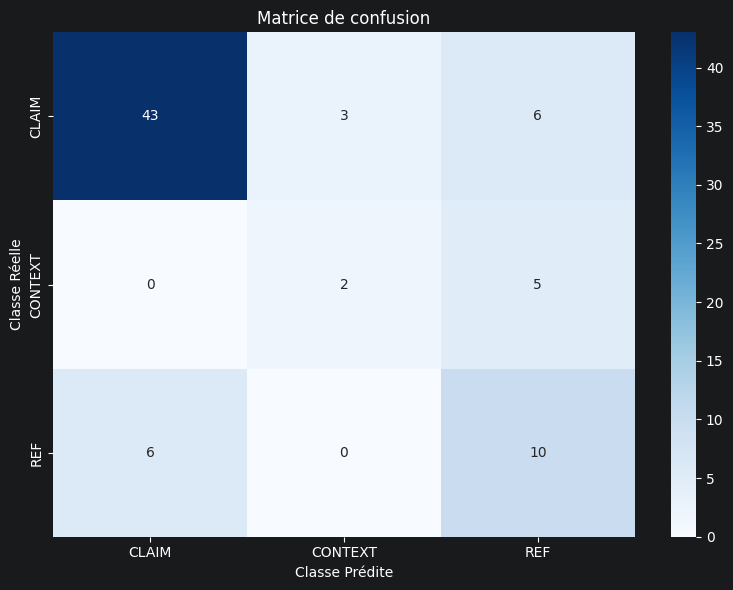

Accuracy  sur le jeu de test : 0.733
###################################
# SAUVEGARDE
###################################
Taille totale : 375
Entraînement final sur : 371 échantillons
Validation isolée sur : 4 échantillons
pipeline créée
{'C': 37.377379784206795, 'gamma': 0.1, 'kernel': 'rbf', 'degree': 2, 'class_weight': 'balanced'}
modèle entrainée
pipeline saved
Le modèle sera sauvegardé ici : C:\Users\foute\Desktop\Classification tweet\classification-tweet\notebooks

--- Vérification sur les données JAMAIS vues ---
modèle chargée
prediction réalisée

--- RÉSULTATS DU TEST ---
Texte : USER think legalise prostitution state decrease sexual abuse reply mam
 => Réel : CLAIM | Prédit : CLAIM
------------------------------
Texte : surprising way social medium affect healthcare social medium frontier url
 => Réel : CLAIM | Prédit : CLAIM
------------------------------
Texte : story tear person expect die childbirth url
 => Réel : REF | Prédit : CONTEXT
------------------------------
Texte

In [126]:
df = add_derived_labels(df)
noms = ["science_related", "claim_or_ref", "type_assertion"]
equilibrage_options = ["class_weight", "SMOTE", "copy", "down", None]
# hastag 1 hasthag+mot, 2 hastag, 3 mot

print("Tâches disponibles :")
print("1 -> SCI vs NON-SCI (science_related)")
print("2 -> {CLAIM, REF} vs CONTEXT (claim_or_ref)")
print("3 -> CLAIM vs REF vs CONTEXT (type_assertion)")
tache_choisie = int(input("Quelle tâche voulez-vous traiter (1/2/3) : "))
colonne_y_choisie = noms[tache_choisie - 1]

config = Config(urls=True, mentions=True, emojis=True, hashtags=3, punct=True, min_df=3, max_df=0.8, ngrams= (1,3), equilibrage="copy", colonne_y=colonne_y_choisie)

X_train, X_test, y_train, y_test = cleanAndSplit(dataframe = df, urls=config.urls, mentions=config.mentions, emojis=config.emojis, hashtags=config.hashtags, punct=config.punct, colonne_y=config.colonne_y)

print("Répartition de la population avant équilibrage")
print(y_train.value_counts())

# à commenter lorsqu'on veut uniquement les hyperparams
evaluate_classifieur(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, 
                          min_df=config.min_df, max_df=config.max_df, ngrams=config.ngrams, equilibrage=config.equilibrage)


# commenter tout ce qui suit lorsqu'on cherchait uniquement à évaluer modele / pretraitements / gestion des desequilibres de classe
name_selected = input("Quel classifieur choisissez-vous\n:")
use_weights = (config.equilibrage == "class_weight")
dico_classifieur = get_dico_classifieur(y_train=y_train, use_class_weight=use_weights)
found = False

while not found:
    if name_selected not in dico_classifieur.keys():
        print(f"Classifieurs possibles : {dico_classifieur.keys()}")
        name_selected = input("Nom incorrect : Quel classifieur choisissez-vous\n:")
    else:
        found = True

result = get_best_params_optuna(name_selected, X_train, y_train, X_test, y_test, config)


save_model(X_train, y_train, X_test, y_test, name_selected, result, config)




### Recherche des meilleurs features

In [127]:
import time
from sklearn.feature_selection import f_classif
import pandas as pd
import numpy as np
import joblib
from pathlib import Path


#####
# Cellule qui gère la génération des meilleurs features, cela génère un top 20 dans un csv par task et par fichier
# dans code_python/pipelines, en s'adaptant au mieux au modèle de classification
###

#----- 0. Redéfinition / debug

#Redifinition de la configuration au cas où (pour pouvoir lancer cette cellule indépendamment du main)
#Peut être supprimé selon l'éxécution ou pas des cellules au dessus)

config = Config(
    urls=True, 
    mentions=True, 
    emojis=False, 
    hashtags=1, 
    punct=True, 
    min_df=3, 
    max_df=0.8, 
    ngrams=(1,2), 
    equilibrage="SMOTE", 
    colonne_y="science_related" 
)

#Besoin de redéfinir ces fonctions pour que ça fonctionne sur Jupyter -> Ne les trouve pas quand il load le pipeline sinon (encore une fois selon exec des cellules au dessus)
def identity_tokenizer(text):
    return text

def to_dense_array(x):
    return x.toarray()

#----- 1. Fonctions

def ranked_features_from_model(pipeline, X_train_raw, y_train):
    
    # Récupérer les étapes clés du pipeline
    vectorizer = pipeline.named_steps["vectorizer"]
    classifier = pipeline.named_steps["classifier"]
    
    # Récupérer les mots (features) générés par TF-IDF
    feature_names = vectorizer.get_feature_names_out()


    # !! Selon le classifieur/modèle il y a plusieurs cas possibles, on essaye d'en gérer le plus possible
    
    # Cas 1: modèles avec feature_importances_ (RF, DT...)
    if hasattr(classifier, "feature_importances_"):
        print("CAS 1")
        scores = classifier.feature_importances_

    # Cas 2: modèles linéaires avec coef_ (LR, SVC kernel='linear')
    elif hasattr(classifier, "coef_"):
        print("CAS 2")
        coef = classifier.coef_
        if coef.ndim > 1:
             scores = np.mean(np.abs(coef), axis=0)
        else:
            scores = np.abs(coef)


    # Cas 3: fallback universel (SVC rbf surtout dans notre cas...)
    # On essaye le plus possible de ne pas tomber dans ce cas, car là on génère "a la main" les features sans profiter
    # de ce qui est intégré au modèle/sa librairie
    # Je précise que l'IA nous a aidé a trouver la stratégie derrière cette technique
    else:
        print("CAS 3")
        print("SVC non linéaire détecté : Utilisation de l'ANOVA (f_classif) pour estimer l'importance des variables instantanément.")
        
        # --- NOUVELLE CORRECTION COMPATIBLE SMOTE ---
        X_train_num = X_train_raw
        for name, step in pipeline.steps[:-1]:
            # 1. On ignore le SMOTE ou tout autre étape d'échantillonnage pour le transform
            if "SMOTE" in type(step).__name__ or hasattr(step, "fit_resample"):
                print(f"   [Info] Étape '{name}' ({type(step).__name__}) ignorée pour la transformation.")
                continue
                
            # 2. Si c'est un transformeur standard scikit-learn
            if hasattr(step, "transform"):
                X_train_num = step.transform(X_train_num)
            # 3. Sécurité pour les FunctionTransformer ou étapes customs
            elif hasattr(step, "fit_transform"):
                X_train_num = step.fit_transform(X_train_num)
            # 4. En dernier recours si c'est une fonction pure
            elif callable(step):
                X_train_num = step(X_train_num)
            else:
                print(f"   [Attention] Étape '{name}' impossible à appliquer, passée.")
        
        # f_classif calcule un score statistique de pertinence pour chaque feature
        f_values, p_values = f_classif(X_train_num, y_train)
        
        # On remplace les potentiels NaN par 0
        scores = np.nan_to_num(f_values, 0)

    ranking = (
        pd.DataFrame({"feature": feature_names, "score": scores})
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )
    return ranking

def feature_ranking_for_task(df, target_col, model_path, config):
    # Obtenir les données textuelles pre-processées
    X_train, X_val, y_train, y_val = cleanAndSplit(
        dataframe=df, 
        urls=config.urls, 
        mentions=config.mentions, 
        emojis=config.emojis, 
        hashtags=config.hashtags, 
        punct=config.punct, 
        colonne_y=target_col
    )

    print(f"Target: {target_col} | X_train: {len(X_train)} | X_val: {len(X_val)}")

    start = time.time()
    print(f"Chargement du modèle: {model_path}")
    pipeline = joblib.load(model_path)
    print(f"Modèle chargé en {time.time() - start:.2f}s")
    
    classifier_type = type(pipeline.named_steps["classifier"]).__name__
    print(f"Modèle utilisé: {classifier_type}")

    start_rank = time.time()
    ranking = ranked_features_from_model(pipeline, X_train, y_train)
    print(f"Ranking terminé en {time.time() - start_rank:.2f}s")
    return ranking


# ----- 2. Execution / "main"

tasks = ["science_related"]  # <------------- A CHANGER POUR SELECTIONNER LA TASK !!

pipelines_dir = Path.cwd().resolve().parent.parent / "pipelines"

# Lister uniquement les fichiers .joblib dans le dossier (sans sous-dossiers pour qu'on puisse garder les old)
model_paths = [p for p in pipelines_dir.iterdir() if p.is_file() and p.suffix == '.joblib']

print(f"Dataset chargé: {df.shape}")
print(f"{len(model_paths)} modèle trouvé dans {pipelines_dir}")

for t in tasks:
    print("--------------------------------------------------")
    print(f"ANALYSE DES FEATURES POUR : {t}")
    print("--------------------------------------------------")

    for model_path in model_paths:
        print(f"\n>>> Traitement du modèle : {model_path.name}")
        try:
            # Extraction des rankings
            r = feature_ranking_for_task(df, t, str(model_path), config)
            
            # On ne garde que le top 20
            top_20 = r.head(20)
            
            print(f"\nTop 20 pour {t} via {model_path.name}")
            print(top_20.to_string(index=False))

            # Sauvegarde dans un fichier spécifique au modèle et à la tâche
            csv_filename = f"features_{model_path.stem}_{t}.csv"
            top_20.to_csv(csv_filename, index=False)
            print(f"Fichier généré: {csv_filename}")
            
        except Exception as e:
            print(f"Erreur lors de l'évaluation du modèle {model_path.name}: {e}")

Dataset chargé: (1140, 9)
1 modèle trouvé dans C:\Users\foute\Desktop\Classification tweet\pipelines
--------------------------------------------------
ANALYSE DES FEATURES POUR : science_related
--------------------------------------------------

>>> Traitement du modèle : test.joblib
Nettoyage du texte en cours...
Séparation du jeu de données train/test...
Target: science_related | X_train: 912 | X_val: 228
Chargement du modèle: C:\Users\foute\Desktop\Classification tweet\pipelines\test.joblib
Modèle chargé en 0.00s
Modèle utilisé: SVC
CAS 2
Ranking terminé en 0.00s

Top 20 pour science_related via test.joblib
  feature    score
      url 2.593132
 increase 1.396965
 url USER 1.287994
eurekamag 1.213288
  support 1.124792
      new 1.077087
    study 1.050980
     find 1.027156
scientist 1.013500
      use 0.952122
     stop 0.951923
  climate 0.831365
    brain 0.831061
     help 0.793788
     risk 0.779025
  url url 0.771241
   accord 0.766598
     lead 0.752158
    level 0.707331
